# Classifiers_KNN_SVM_MLP
This project's goal is to construct, train and analyze performances between the following classifiers: K Nearest Neighbors;  Support Vector Machines; Multi-Layer Perceptron

### Importing Libraries

In [140]:
from sklearn.datasets import load_iris
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
# for the classifiers
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier as KNN # K-Nearest Neighbors
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.neural_network import MLPClassifier as MLP # Multi-layer Perceptron

## Iris Dataset

Looking at the Iris dataset and testing the KNN classifier on it. 

In [141]:
X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
knn = KNN().fit(X_tr, y_tr)
print("Accuracy: " + str(knn.score(X_te, y_te)) + "/1.0\n")

for i in range(10):
    print(X_te[i], y_te[i], knn.predict([X_te[i]]))

Accuracy: 1.0/1.0

[4.4 3.  1.3 0.2] 0 [0]
[6.1 3.  4.9 1.8] 2 [2]
[4.9 2.4 3.3 1. ] 1 [1]
[5.  2.3 3.3 1. ] 1 [1]
[4.4 3.2 1.3 0.2] 0 [0]
[6.3 3.3 4.7 1.6] 1 [1]
[4.6 3.6 1.  0.2] 0 [0]
[5.4 3.4 1.7 0.2] 0 [0]
[6.5 3.  5.2 2. ] 2 [2]
[5.4 3.  4.5 1.5] 1 [1]


## Digits Dataset

Looking at the Digits dataset by printing first 10 images with their labels, the number of samples for each label and its shape.

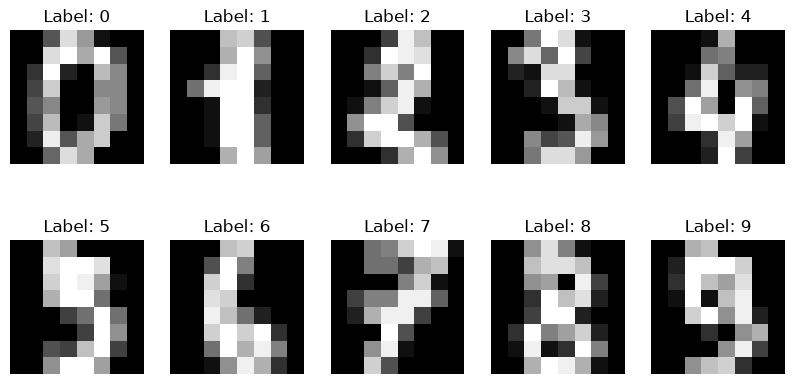

0:178   1:182   2:177   3:183   4:181   5:182   6:181   7:179   8:174   9:180  
X shape: (1797, 64) | y shape: (1797,)


In [142]:
digits = load_digits()
X, y = digits.data, digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.axis('off')
    plt.imshow(digits.images[i], cmap='grey')
    plt.title(f"Label: {digits.target[i]}")
plt.show()

print(*(str(i) + ":" + str(np.bincount(y)[i]) + "  " for i in range(10)))
print("X shape: {} | y shape: {}".format(X.shape, y.shape))

### Classifiers

>Note: Since the digits dataset has a small range of values, using StandarScaler to scale the data may not be necessary. Either way, I'll include both to see if there are any performance differences.

#### K Nearest Neighbors
- With StandardScaler:

In [143]:
pipe = make_pipeline(StandardScaler(), KNN())
grid = GridSearchCV(pipe, {"kneighborsclassifier__n_neighbors": [1, 3, 5, 7], "kneighborsclassifier__weights": ["uniform", "distance"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

# Just testing stuff with pandas
results = pd.DataFrame(grid.cv_results_)
print(results.iloc[grid.best_index_])

{'kneighborsclassifier__n_neighbors': 5, 'kneighborsclassifier__weights': 'uniform'} 0.9749298296554393
Accuracy: 0.964/1.000

mean_fit_time                                                                       0.002672
std_fit_time                                                                        0.000453
mean_score_time                                                                     0.014365
std_score_time                                                                      0.000849
param_kneighborsclassifier__n_neighbors                                                    5
param_kneighborsclassifier__weights                                                  uniform
params                                     {'kneighborsclassifier__n_neighbors': 5, 'knei...
split0_test_score                                                                   0.993056
split1_test_score                                                                   0.982639
split2_test_score                   

- Without StandardScaler:

In [144]:
grid = GridSearchCV(KNN(), {"n_neighbors": [1, 3, 5, 7], "weights": ["uniform", "distance"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'n_neighbors': 1, 'weights': 'uniform'} 0.9902463221060781
Accuracy: 0.986/1.000



---
#### Support Vector Machines
- With StandardScaler:

In [145]:
pipe = make_pipeline(StandardScaler(), SVC())
grid = GridSearchCV(pipe, {"svc__C": [0.1, 1, 10], "svc__gamma": ["scale", 0.01, 0.001], "svc__kernel": ["linear", "rbf"]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'} 0.9832970383275261
Accuracy: 0.975/1.000



- Without StandardScaler:

In [146]:
grid = GridSearchCV(SVC(), 
                    [{"C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.001, 0.0005, 0.0001], "kernel": ["rbf"]},
                    {"C": [0.1, 1, 10, 100], "kernel": ["linear"]}], 
                    cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'C': 1, 'gamma': 0.0005, 'kernel': 'rbf'} 0.9902560007742934
Accuracy: 0.992/1.000



>At first C's highest value was 10 and gamma's lowest was 0.001 and the grid search chose those 2 results, so I added [100] and [0.0005, 0.0001] respectively to see if it was because of the boundaries.
Results: The best parameters became C=1 and gamma=0.0005, which means they moved inside the grid and the boundaries were affecting the results.

---
##### Conclusions about StandardScaler for KNN and SVM
For this dataset, using StandardScaler has a negative effect, the accuracy is lower. This is because all the pixels are in the same 0-16 range and with scaling, it makes every pixel's variance equal and since KNN and SVM are distance-based classifiers, they don't have weight mechanisms like MLP to give more importance to the pixels that are more relevant to the classification. 

---
#### Multi-Layer Perceptron
- With StandardScaler:

In [147]:
pipe = make_pipeline(StandardScaler(), MLP())
grid = GridSearchCV(pipe, {"mlpclassifier__hidden_layer_sizes": [(64,), (128,), (128, 64)], "mlpclassifier__alpha": [0.0001, 0.001, 0.01], "mlpclassifier__max_iter": [1000], "mlpclassifier__random_state": [42]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'mlpclassifier__alpha': 0.0001, 'mlpclassifier__hidden_layer_sizes': (64,), 'mlpclassifier__max_iter': 1000, 'mlpclassifier__random_state': 42} 0.9784214092140922
Accuracy: 0.981/1.000



- Without StandardScaler:

In [148]:
grid = GridSearchCV(MLP(), {"hidden_layer_sizes": [(64,), (128,), (128, 64)], "alpha": [0.0001, 0.001, 0.01], "max_iter": [1000], "random_state": [42]}, cv=5)
grid.fit(X_tr, y_tr)
print(grid.best_params_, grid.best_score_)
print("Accuracy: {:.3f}".format(grid.score(X_te, y_te)) + "/1.000\n")

{'alpha': 0.01, 'hidden_layer_sizes': (128,), 'max_iter': 1000, 'random_state': 42} 0.9728561749903214
Accuracy: 0.975/1.000



### Loop for results gathering

KNN:

Best Params: {'clf__n_neighbors': 1, 'clf__weights': 'uniform', 'scaler': 'passthrough'}
Best Score CV: 0.990/1.000
Accuracy: 0.986/1.000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



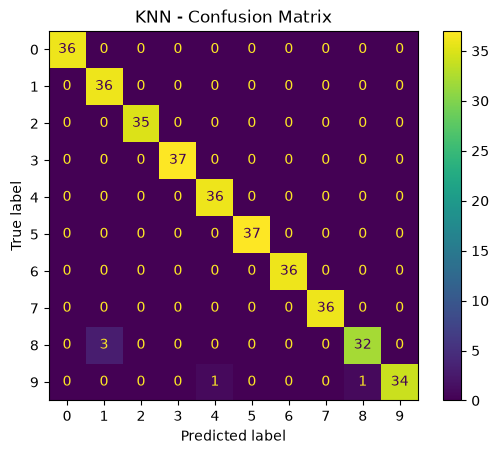

SVM:

Best Params: {'clf__C': 1, 'clf__gamma': 0.0005, 'clf__kernel': 'rbf', 'scaler': 'passthrough'}
Best Score CV: 0.990/1.000
Accuracy: 0.992/1.000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.94      0.97        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



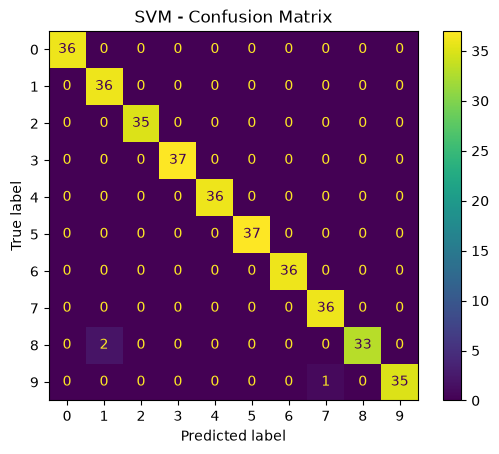

MLP:

Best Params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64,), 'scaler': StandardScaler()}
Best Score CV: 0.978/1.000
Accuracy: 0.981/1.000

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0.94      0.94        36
           2       0.95      1.00      0.97        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      0.97      0.99        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       0.97      1.00      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



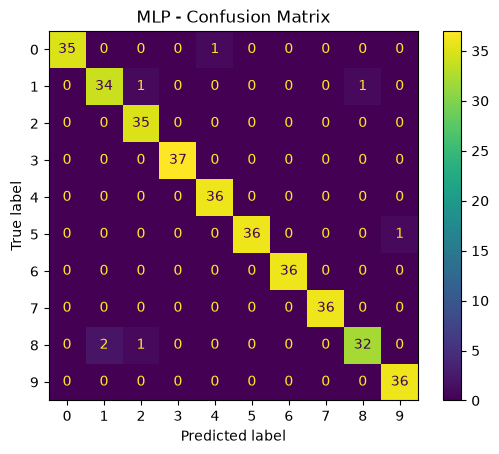

In [ ]:
data_scaling = list()
data_models = list()
models = dict()

classifiers = {"KNN": (KNN(), {"scaler": [StandardScaler(), "passthrough"], "clf__n_neighbors": [1, 3, 5, 7], "clf__weights": ["uniform", "distance"]}), 
               "SVM": (SVC(), [{"scaler": [StandardScaler(), "passthrough"], "clf__C": [0.1, 1, 10, 100], "clf__gamma": ["scale", 0.01, 0.001, 0.0005, 0.0001], "clf__kernel": ["rbf"]},
                       {"scaler": [StandardScaler(), "passthrough"], "clf__C": [0.1, 1, 10, 100], "clf__kernel": ["linear"]}]), 
               "MLP": (MLP(max_iter=1000, random_state = 42), {"scaler": [StandardScaler(), "passthrough"], "clf__hidden_layer_sizes": [(64,), (128,), (128, 64)], "clf__alpha": [0.0001, 0.001, 0.01]})}

for name, (clf, params) in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        grid = GridSearchCV(pipe, params, cv=5)
        grid.fit(X_tr, y_tr)

        # Storing each winner model
        models[name] = grid.best_estimator_

        # Getting the best CV scores w/ and w/o scaling for each model
        results = pd.DataFrame(grid.cv_results_)
        scaled = results["param_scaler"] != "passthrough"
        best_scaled = results.loc[scaled, "mean_test_score"].max()
        best_unscaled = results.loc[~scaled, "mean_test_score"].max() 

        # Transfering best_params_ value into readable content to store in the pandas DataFrame
        best_params = grid.best_params_
        scaled_used = "Yes" if best_params["scaler"] != "passthrough" else "No"
        params_str = ", ".join(f"{key.replace('clf__', '')} = {value}" for key, value in best_params.items() if key != "scaler")
        
        # Calculating time prediction to store it
        t0 = time.perf_counter()
        y_pred = grid.predict(X_te)
        pred_time = time.perf_counter() - t0

        # Storing accuracy to avoid re-scoring since it's used more than once
        accuracy = accuracy_score(y_te, y_pred)

        # Table for comparing each model w/ and w/o scaling
        data_scaling.append({"Classifier": name,
                             "Best CV Scaled": best_scaled,
                             "Best CV Unscaled": best_unscaled,
                             "Winner": "Scaled" if best_scaled > best_unscaled else ("Unscaled" if best_scaled < best_unscaled else "Both"),
                             "Difference": abs(best_scaled - best_unscaled)})

        # Table for comparison between models
        data_models.append({"Classifier": name,
                            "Scaled": scaled_used,
                            "Best Parameters": params_str,
                            "CV mean": grid.best_score_, 
                            "CV std": grid.cv_results_["std_test_score"][grid.best_index_],
                            "Test accuracy": accuracy,
                            "F1": f1_score(y_te, y_pred, average="macro"), 
                            "Training time (ms)": grid.refit_time_ * 1000, # s -> ms
                            "Prediction time (ms)": pred_time * 1000}) # s -> ms

        print("{}:\n\nBest Params: {}\nBest Score CV: {:.3f}/1.000\nAccuracy: {:.3f}/1.000\n".format(name, grid.best_params_, grid.best_score_, accuracy))
        
        print(classification_report(y_te, y_pred, zero_division=0))

        ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

### Results Table

In [150]:
pd_data_scaling = pd.DataFrame(data_scaling).set_index("Classifier").round(4)
pd_data_scaling

,Best CV Scaled,Best CV Unscaled,Winner,Difference
Classifier,,,,
KNN,0.9749,0.9902,Unscaled,0.0153
SVM,0.9833,0.9903,Unscaled,0.0070
MLP,0.9784,0.9729,Scaled,0.0056


  For this dataset, using StandardScaler has a negative effect on KNN and SVM and slightly helps MLP. This is because all the pixels are in the same 0-16 range and with scaling, it makes every pixel's variance equal and since KNN and SVM are distance-based classifiers, they don't have weight mechanisms like MLP to give more importance to the pixels that are more relevant to the classification. 

In [151]:
pd_data_models = pd.DataFrame(data_models).set_index("Classifier").round(4)
pd_data_models

,Scaled,Best Parameters,CV mean,CV std,Test accuracy,F1,Training time (ms),Prediction time (ms)
Classifier,,,,,,,,
KNN,No,"n_neighbors = 1, weights = uniform",0.9902,0.0081,0.9861,0.9859,0.8788,12.1127
SVM,No,"C = 1, gamma = 0.0005, kernel = rbf",0.9903,0.0060,0.9917,0.9916,26.7897,19.6318
MLP,Yes,"alpha = 0.0001, hidden_layer_sizes = (64,)",0.9784,0.0095,0.9806,0.9803,958.7498,0.9630


### Conclusions for the classifiers
**Accuracy:** All three classifiers perform very well on the digits dataset (98–99%). On the test set, SVM was best (99.2%, 3 errors), followed by KNN (98.6%, 5 errors) and MLP (98.1%, 7 errors). For the Cross-Validation, SVM and KNN are practically tied (0.9903 vs 0.9902), while MLP is about 1.2 points lower (0.978).

**F1 vs accuracy:** F1 is almost identical to accuracy for every model, which is expected because the classes are balanced, this makes accuracy a fair metric.

**Stability:** SVM has the lowest CV standard deviation (0.0060), meaning its performance depends the least on which data it is trained on. MLP is the least stable (0.0095).

**Best hyperparameters:**
- KNN chose k = 1: only the nearest training image is enough, which probably indicates each digit class forms tight and clean clusters.
- SVM chose the RBF kernel over the linear one, so non-linear decision boundaries help. The very small gamma of 0.0005 makes sense for unscaled pixels, since squared distances between images are large.
- MLP chose the smallest network with one hidden layer of 64 neurons and the smallest regularization, it's a small dataset, so no need for a large network which already limits overfitting, so stronger regularization only reduced accuracy

**Computational cost:** The models show opposite trade-offs:
- Training: KNN ≈ 0.9 ms, SVM ≈ 27 ms, MLP ≈ 960 ms. MLP is about 1000× slower than KNN.
- Prediction: KNN ≈ 12 ms, SVM ≈ 20 ms, MLP ≈ 1 ms. MLP is instant compared to KNN and SVM.

>KNN learns quickly but predicts slowly and MLP trains slowly but predicts quickly. SVM is in the middle for both.

**Overall:** On this dataset, SVM gives the best balance: the highest test accuracy, the most stable CV scores and a reasonable cost. MLP would be preferred if prediction speed mattered most, since it predicts a lot faster for about 1 point less accuracy. KNN is the simplest strong baseline, but it would most probably scale the worst to larger datasets.

### Mislabeled Images

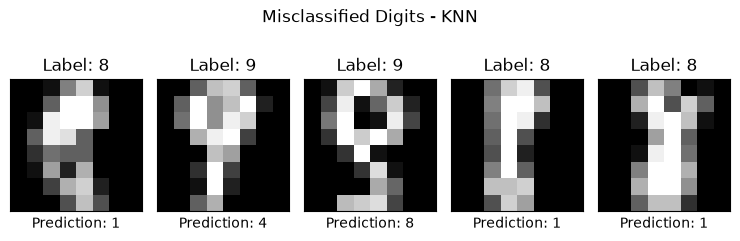

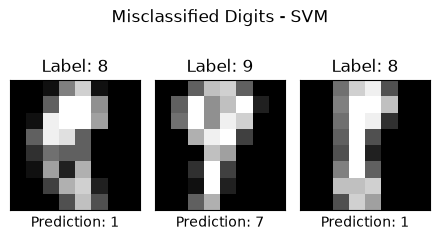

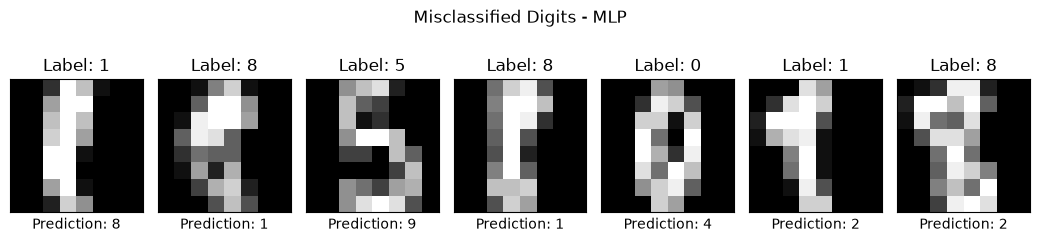

In [152]:
for name, model in models.items():
    y_pred = model.predict(X_te)
    wrong = np.where(y_pred != y_te)[0]
    n_cols = min(10, len(wrong))
    n_rows = int(np.ceil(len(wrong) / n_cols))

    plt.figure(figsize=(1.5 * n_cols, 2.5 * n_rows))
    plt.suptitle(f"Misclassified Digits - {name}")

    for k, i in enumerate(wrong):
        plt.subplot(n_rows, n_cols, k + 1)
        plt.imshow(X_te[i].reshape(8, 8), cmap="gray")
        plt.title(f"Label: {y_te[i]}")
        plt.xlabel(f"Prediction: {y_pred[i]}")
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()


#### Conclusions about mislabeled images
Some of the mislabeled images are simply hard to classify even for humans, maybe also due to the resolution. Two images were mislabeled by all 3 classifiers, both 8's misclassified as 1's. 